# Day 4 - Univariate Exploratory Data Analysis

Univariate EDA is used to explore one feature at a time.

It helps us understand the values, distribution, and possible outliers.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("insurance copy.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Dataset Shape 


In [3]:
print(df.shape)

(1338, 7)


The dataset contains 1338 rows and 7 columns

## dataset information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## Summary Statistics

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


The table shows the minimum, maximum, mean, and other statistics for the numeric columns

## Histogram

A histogram shows how the values are distributed.

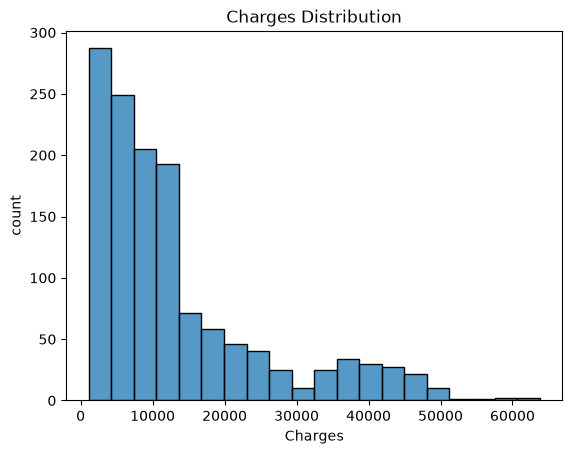

In [6]:
sns.histplot(df["charges"],
 bins=20)

plt.title("Charges Distribution")
plt.ylabel("count")
plt.xlabel("Charges")

plt.show()

The histogram shows how the values are spread
Most values are in the lower range, while a few values are much higher

## Box plot 
 a box plot help us to find outliers

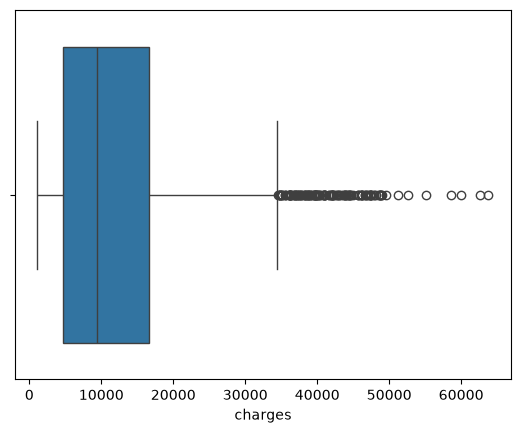

In [7]:
sns.boxplot(x=df["charges"])
plt.show()

The circles outside the box are possible outliers.

## Detect Outliers

In [8]:
d1 = df["charges"].quantile(0.25)
d3 = df["charges"].quantile(0.75)
IQR = d3 - d1 

l = d1 -1.5 *IQR # lower
u =d3 +1.5*IQR #UPPER 
print("lower",l)
print("upper",u)

lower -13109.1508975
upper 34489.350562499996


In [9]:
outliers =df[(df["charges"] < l)|(df["charges"] > u)]
print(outliers.shape)

(139, 7)


The rows outside the lower and upper limits are considered outliers.

# clean 

In [10]:
out_clean =df[(df["charges"] >=l) &(df["charges"] <= u)]
print("clean",out_clean.shape)
print("original",df.shape)
print("outliers",outliers.shape)

clean (1199, 7)
original (1338, 7)
outliers (139, 7)


## Charges After Removing Outliers

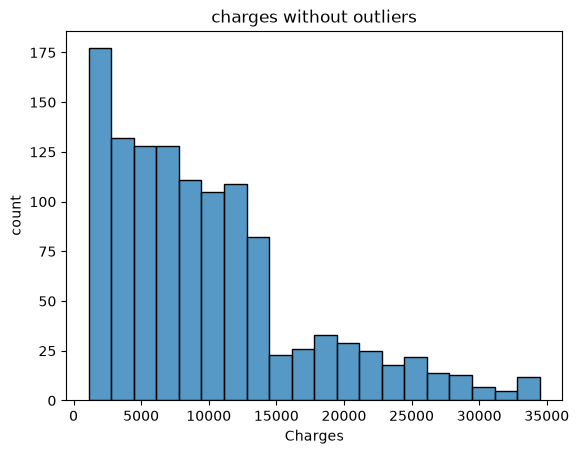

In [11]:
sns.histplot(out_clean["charges"], bins=20)

plt.title("charges without outliers")
plt.xlabel("Charges")
plt.ylabel("count")
plt.show()

After removing the outliers, the charges distribution became easier to understand.

## Hands-On Lab

 Step 1: Load a provided real dataset and produce a histogram for each numeric variable

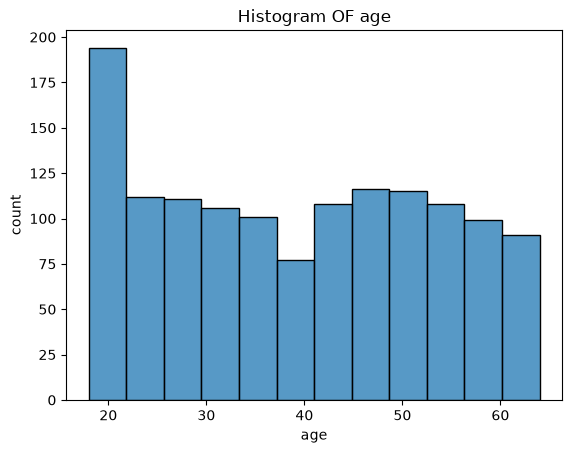

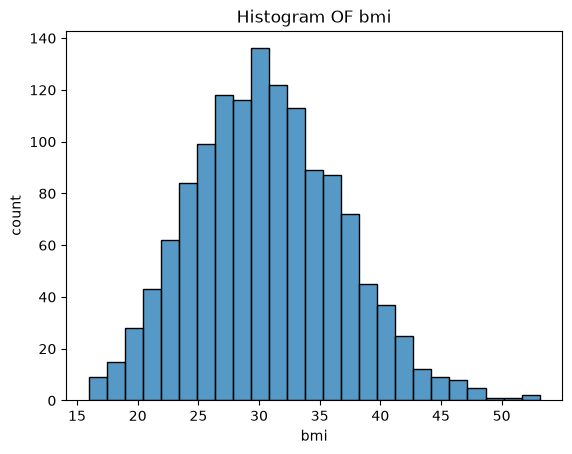

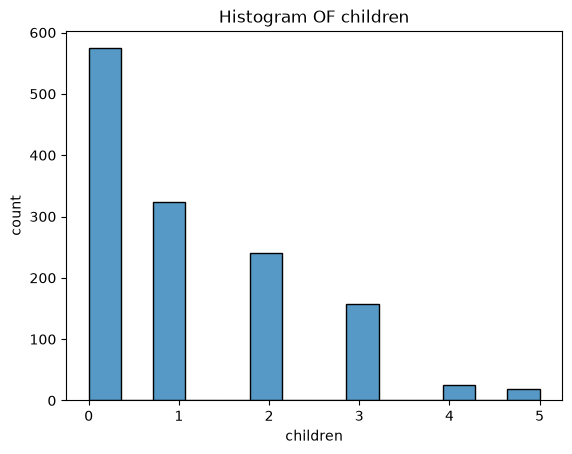

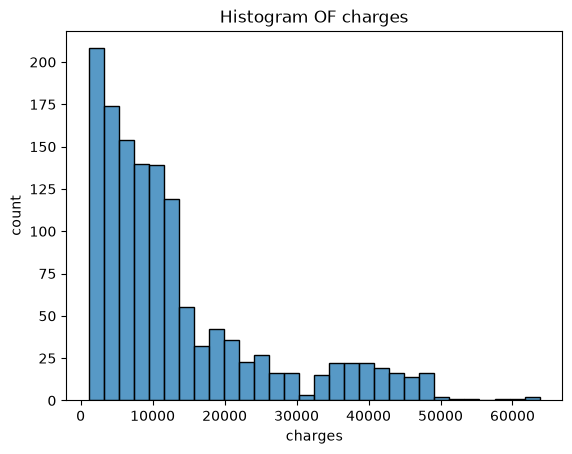

In [12]:
c = df.select_dtypes(include="number").columns
for i in c :
    sns.histplot(df[i])
    plt.title(F"Histogram OF {i}")
    plt.xlabel(i)
    plt.ylabel("count")
    plt.show()

## Step 2: 
Produce a box plot for the key numeric variables and identify any outliers visually.

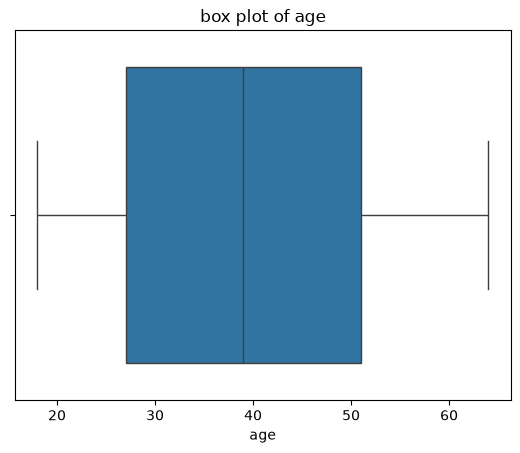

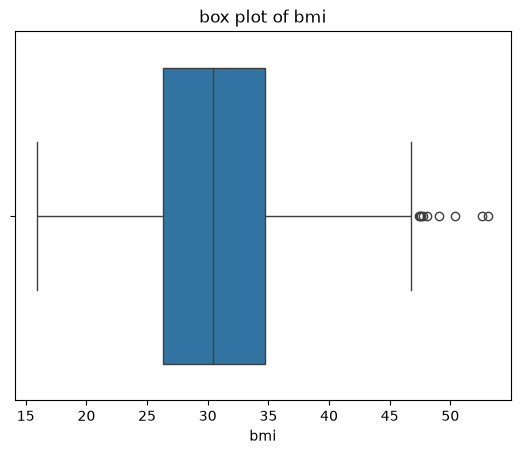

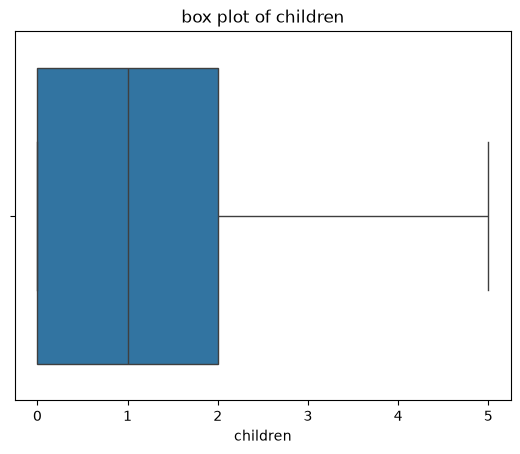

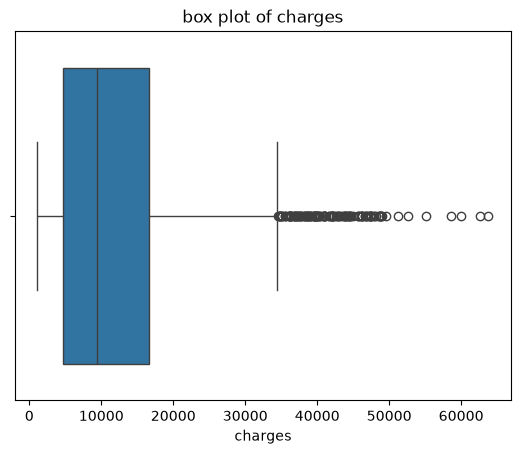

In [13]:
c = df.select_dtypes(include="number").columns
for i in c :
    sns.boxplot(x=df[i])
    plt.title(f"box plot of {i}")
  
    plt.show()

### Observation

The box plots help identify possible outliers.

Some numeric variables contain values that are far from the rest of the data.

## step 3 :
 Apply the IQR method in code to flag outliers in at least one column, and decide (with justification) 
how to handle them.

In [14]:
d1 = df["charges"].quantile(0.25)
d3 = df["charges"].quantile(0.75)
IQR = d3 - d1 

l = d1 -1.5 *IQR # lower
u =d3 +1.5*IQR #UPPER 
print("lower",l)
print("upper",u)

lower -13109.1508975
upper 34489.350562499996


In [15]:
outliers = df[(df["charges"] < l) | (df["charges"] > u)]

print(outliers.shape[0])

139


In [16]:
out_clean =df[(df["charges"] >=l) &(df["charges"] <= u)]
print("clean",out_clean.shape)
print("original",df.shape)


clean (1199, 7)
original (1338, 7)


### Decision

I kept the original dataset and created another dataset without the outliers.

I did not delete the outliers permanently because high insurance charges may be real values, not errors.

The cleaned dataset was created only to compare the distribution

## step 4 
Produce a count plot for each categorical variable and note any class imbalance

smoker
no     1064
yes     274
Name: count, dtype: int64


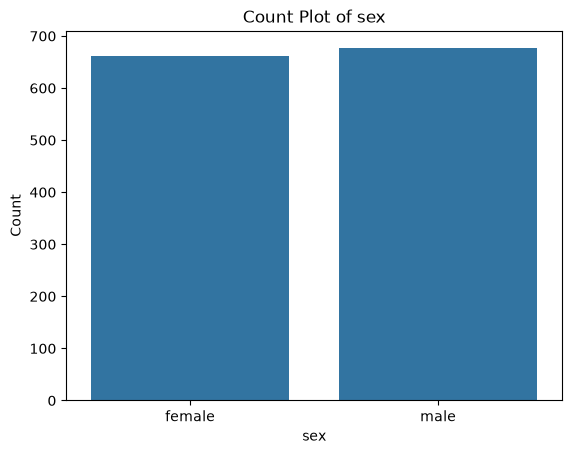

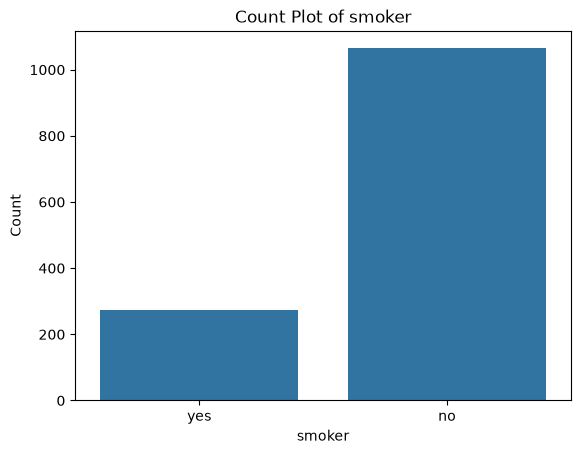

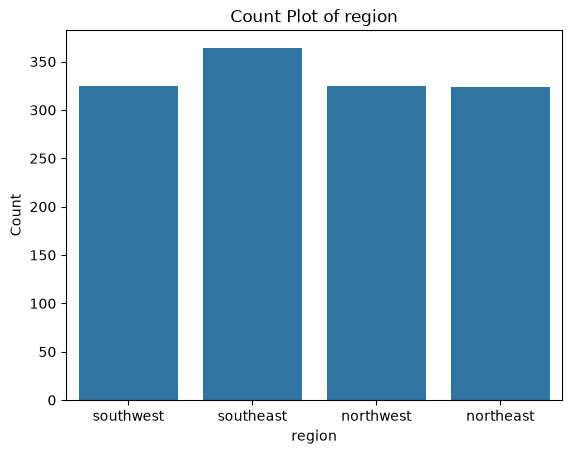

In [20]:
c = df.select_dtypes(include=["str", "object", "category"]).columns


print(df["smoker"].value_counts())
for co in c:
 
    sns.countplot(data=df, x=co)
    plt.title(f"Count Plot of {co}")
    plt.xlabel(co)
    plt.ylabel("Count")
    plt.show()

## step 5 
: Document what each distribution reveals in Markdown cells.

## Observations

### Histogram
- The age of the subjects can be distributed across several different values.
- The body mass index (BMI) of most people is close to a normal distribution with a slight right skew.
- The distribution of the insurance charges is right-skewed because only a small number of people have insurance charges that are very high relative to the rest of the population.

### Box Plot
- The charges column contains several outliers.
- The age and BMI columns have fewer outliers.

### Count Plot
- The sex column of this dataset is almost balanced between males and females.
- The smoker column is imbalanced as there are more people who have never smoked than those who have smoked.
- The region column is fairly balanced across all regions.

### Conclusion
The dataset contains both balanced and imbalanced variables. The charges variable shows a skewed distribution with outliers and the categorical variables have different frequencies of each category.